# Bearing diagnosis tutorial

In [1]:
## Do not edit this cell
# await __import__("piplite").install('openconmo', deps=False)
import numpy as np
import scipy
import tqdm
import matplotlib.pyplot as plt

# Bearing Characteristic Frequency Guide

Bearing fault frequencies are the characteristic frequencies of any rolling element bearing which are used to identify local bearing damage. Diagnosis of bearing system begins by calculating these frequencies before analysis.

<figure style="text-align: center;">
  <img src="figures/fault_frequencies_figure.png" alt="Bearing faults">
  <figcaption>Bearing faults with corresponding time domain vibration responses [1].</figcaption>
</figure>

---

The following diagrams illustrate the bearing components and dimensions used in the formulas.


<div style="display: flex; align-items: flex-start; justify-content: space-between; gap: 10px;">

<div style="flex: 1; text-align: center; min-width: 500px;">
  <img src="figures/bearing.png" alt="Bearing faults" height="400">
  <p>Figure 1: Bearing elements.</p>
</div>

<div style="flex: 3; min-width: 400px;">

<p>Table 1: Bearing Fault Frequency Formulas<p>

| Fault Frequency Name | Formula |
| :--- |  :--- |
| **Ball pass frequency, outer race** | $BPFO = \frac{nf_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball pass frequency, inner race** | $BPFI = \frac{nf_r}{2} \left( 1 + \frac{d}{D} \cos \phi \right)$ |
| **Fundamental train frequency** | $FTF = \frac{f_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball (roller) spin frequency**  | $BSF = \frac{Df_r}{2d} \left( 1 - \left[ \frac{d}{D} \cos \phi \right]^2 \right)$ |

## Variable Definitions
* $n$ = Number of rolling elements
* $f_r$ = Shaft rotation frequency
* $d$ = Rolling element diameter
* $D$ = Bearing pitch diameter
* $\phi$ = Angle of the load from the radial plane
</div>

</div>

---

## Task 1. Calculate bearing fault frequencies for a bearing 6205-2RS JEM SKF 
## Bearing Specifications

The table below details the specifications for a specific bearing model.

| Specification | **6205-2RS JEM SKF (Drive-End Bearing)** |
| :--- | :--- |
| Inside diameter [mm] | 25.0 |
| Outside diameter [mm] | 52.0 |
| Pitch diameter [mm] | 39.0 |
| Ball diameter [mm] | 7.94 |
| Thickness [mm] | 15.0 |
| Number of balls | 9 |
| Contact angle [degrees] | 3.134 |

In [2]:
'''
a) Calculate the fault frequencies in Hz
'''
## Your code begins here. Expected amount of code: 4-9 lines
f_r = 1730 / 60
n = 9
d = 7.94e-3
D = 39e-3
phi = 3.134 / 180 * np.pi
#phi = 0
BPFO_Hz = (n * f_r / 2) * (1 - (d / D) * np.cos(phi))
BPFI_Hz = (n * f_r / 2) * (1 + (d / D) * np.cos(phi))
FTF_Hz  = (f_r / 2)      * (1 - (d / D) * np.cos(phi))
BSF_Hz  = (D * f_r / (2 * d)) * (1 - ((d / D) * np.cos(phi))**2)
## Your code ends here

In [3]:
'''
b) Express the frequencies as multiples of the rotational frequency
'''
## Your code begins here Expected amount of code: 4 lines
# BPFO = BPFO_Hz / f_r
BPFO = 3.585
BPFI = BPFI_Hz / f_r
FTF  = FTF_Hz / f_r
BSF  = BSF_Hz / f_r
## Your code ends here  

print(f"BPFO: {BPFO:.4f}")
print(f"BPFI: {BPFI:.4f}")
print(f"FTF: {FTF:.4f}")
print(f"BSF: {BSF:.4f}")

BPFO: 3.5850
BPFI: 5.4148
FTF: 0.3984
BSF: 2.3544


a.) Using SciPy.signal, NumPy, and the oneside_fft method (implemented below), implement a method to calculate the squared envelope spectrum of a signal using the algorithm described below.

## Envelope Spectrum
Bearing faults occur as impulses in vibration measurements. Because impulses are not well defined using sinusoids it is best practice to use the enveloping methods.

Envelope of any signal can be calculated using the [Hilbert transform](https://en.wikipedia.org/wiki/Analytic_signal). Essentially the impulsive time history signal is transformed into smooth signal which resembles a sinusoidal function with frequency related to the fault frequencies. Then with spectral analysis the fault frequencies can be identified.

The single most powerful tool for bearing fault diagnosis is the envelope spectrum. Below is shown step by step how the spectrum can be computed. 
***
**Input:** Signal $\mathbf{x}$, sampling frequency $f_s$  
**Output:** Frequency vector $\mathbf{f}$, envelope spectrum $\mathbf{X}$  

1. $\mathbf{a} \leftarrow \text{Hilbert}(\mathbf{x})$ $\;\;\quad\;\qquad \triangleright$ Form the analytic signal  
2. $\mathbf{e} \leftarrow |\mathbf{a}|$ $\;\quad\qquad\qquad\qquad \triangleright$ Compute the envelope  
3. $\mathbf{e}_{\text{sq}} \leftarrow \mathbf{x}\odot\mathbf{x}$ $\;\quad\qquad\qquad \triangleright$ Compute the squared envelope signal  
4. $\mathbf{X} \leftarrow \text{FFT}(\mathbf{e}_{\text{sq}}, f_s)$ $\;\;\;\qquad \triangleright$ Compute the FFT  

**Return** $\mathbf{f}$, $\mathbf{X}$
***

## Task 2: Implement the Envelope algorithm

In [4]:
# You can use these hilbert and fft functions
from scipy.signal import hilbert
from numpy.fft import fft

def envelope(x, fs):
    """
    Parameters
    ----------
    x : ndarray
        The input raw signal.
    Returns
    -------
    X : ndarray
        Amplitude of the squared envelope spectrum.
    """
    

    ## Your code begins here. Expected amount of code: 4-6 lines
    analytic_signal = ...
    envelope = ...
    squared_envelope = ...
    X = ...
    ## Your code ends here

    
    analytic_signal = scipy.signal.hilbert(x)
    envelope = np.abs(x)
    squared_envelope = envelope ** 2
    X = fft(squared_envelope)
    
    N = len(x)
    X = np.abs(X[:N//2]) * (2 / N)
    f = np.linspace(0, fs / 2, N // 2)
    return f, X
    

# Task 3: Plot the envelope spectrum
Your task is to perform the envelope analysis for the given vibration data. Plot the envelope spectrum for the vibration data and identify the fault frequency.

In [5]:
"""Run this cell to load the vibration data to variable called signal"""
mat_file = "data.mat"
data = scipy.io.loadmat(mat_file) # Loads the .mat file data into a Python variable
keys = data.keys() # Gets the keys of the loaded data
De_key = next((key for key in keys if "DE" in key), None) # Finds the key that contains "DE"
signal = data[De_key].flatten() if De_key else None # Extracts the signal data

(61285,)
(61285,)


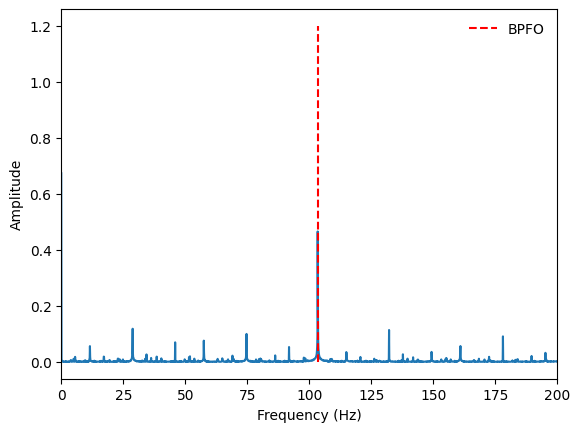

In [6]:
# Your code begins here. Expected amount of code: 4-6 lines
fs = 12e3
sq_env_f, sq_env = envelope(signal, fs)
print(sq_env_f.shape)
print(sq_env.shape)
plt.plot(sq_env_f, sq_env)
plt.xlim((0, 200))

plt.vlines(x=[BPFO_Hz], ymin=0, ymax=1.2, colors="r", linestyles="dashed", label=rf"BPFO")
# [plt.vlines(x=[BPFO_Hz * i], ymin=0, ymax=1.2, colors="r", linestyles="dashed", label=rf"BPFO$\times${i}") for i in range(1, 12)]
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend(frameon=False)
plt.show()

# Your code ends here

## OpenConmo demonstration

[OpenConmo](https://github.com/Aalto-Arotor/openConMo) is aPython library for vibration signal–based condition monitoring, developed at Aalto University, Finland.
The objectives of the library are:
* Provide easy access to reproducing signal based condition monitoring papers
* Enable comparison of AI/ML based techniques with conventional signal processing tools

The library is well suited also for signal processing of bearing vibration signals. It includes implementations for the envelope spectrum, [DRS](https://doi.org/10.1016/S0888-3270(03)00013-X), [Fast Kurtogram](https://doi.org/10.1016/j.ymssp.2005.12.002), [Cepstrum prewhitening](https://doi.org/10.1016/j.ymssp.2012.11.001).

## Discrete/random separation (DRS)

Discrete/Random Separation (DRS) is a signal processing technique used to decompose a single vibration measurement into its periodic (discrete) and non-deterministic (random) components. The method exploits the fact that periodic signals remain predictable over long intervals, while broadband noise loses correlation quickly.

Rotating system with different elements such as gears, couplings and bearings are all visible in the vibration measurement. This can make distinguishing bearing damage from other components difficult. The DRS is a method which uses the randomness of bearing fault occurrence to filter out deterministic components for example gear vibraition away from the original signal. The reason bearing signals are more random than deterministic is because of the rolling elements often slip and dont rotate with constant contact. After using the DRS filter only signal from bearing fault should remain.

## Task 4. Experiment with the DRS within below code block
The block contains pre programmed synthetic signal which resembles a bearing fault scenario where the signal is corrupted also with deterministic (sinusoidal) gear induced vibration as well as some electrical measurement noise.

In [249]:
# Run this cell to import necessary functions from openconmo library
from openconmo.benchmark_methods import envelope, DRS

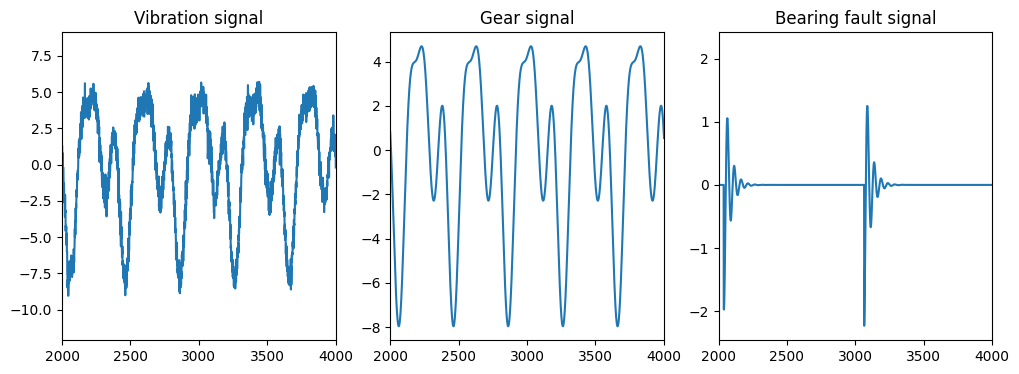

In [235]:
fs = 20_000
x = np.linspace(0, 10, int(10*fs))
gear_signal = np.sum(np.arange(4, 1, -1)[:, np.newaxis] * np.cos(2 * np.pi * 50 * np.arange(1, 4, 1)[:, np.newaxis] * x + np.random.uniform(0, 2*np.pi, 3)[:, np.newaxis]), axis=0)
# gear_signal = 0
freq = 400
lamda = 500
A = 3

# Adjust these parameters to change the timing
interval_min = 950  # Minimum samples between starts
interval_max = 1050 # Maximum samples between starts
impulse_len = 1000

total_len = len(x)
bearing_fault_signal = np.zeros(total_len)
current_pos = 0

while current_pos < total_len:
    # Generate the single impulse
    t_impulse = x[:impulse_len]
    tau = np.random.uniform(0, 0.001)
    impulse = A * np.exp(-lamda * (t_impulse + tau)) * \
              np.sin(2 * np.pi * freq * (t_impulse - tau))
    # Determine random step size
    step = np.random.randint(interval_min, interval_max + 1)
    # Place impulse (handling end of array)
    end_pos = min(current_pos + impulse_len, total_len)
    actual_fill = end_pos - current_pos
    bearing_fault_signal[current_pos:end_pos] = impulse[:actual_fill]
    current_pos += step
    
noise = 0.5 * np.random.normal(size=x.shape) 
signal = gear_signal + bearing_fault_signal + noise
fs = 1 / (x[1] - x[0])
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(signal)
plt.xlim(2000,4000)
plt.title("Vibration signal");
plt.subplot(1, 3, 2)
plt.plot(gear_signal)
plt.xlim(2000,4000)
plt.title("Gear signal");
plt.subplot(1, 3, 3)
plt.plot(bearing_fault_signal)
plt.xlim(2000,4000)
plt.title("Bearing fault signal");

Building DRS filter: 100%|██████████| 1920/1920 [00:00<00:00, 7033.51it/s]


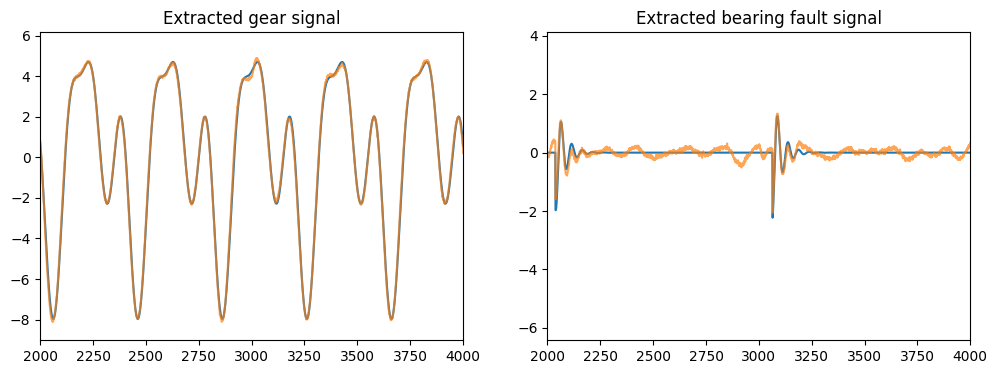

In [247]:
N = 2000
Delta = 4000
random, deterministic = DRS(signal, N, Delta);

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(gear_signal)
plt.plot(deterministic,alpha=0.7)
plt.title("Extracted gear signal")
plt.xlim(2000,4000);

plt.subplot(1,2,2)
plt.plot(bearing_fault_signal)
plt.plot(random-noise,alpha=0.7)
plt.title("Extracted bearing fault signal")
plt.xlim(2000,4000);

(0.0, 300.0)

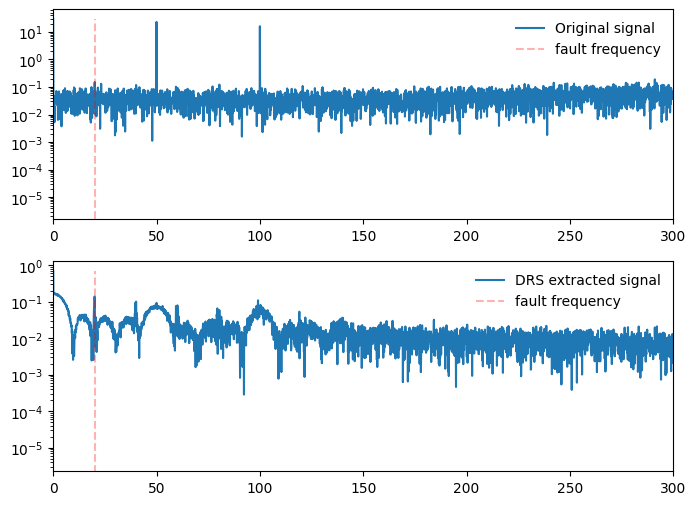

In [245]:
f_env, X_env = envelope(signal, fs)
f_drs, X_drs = envelope(random, fs)

plt.figure(figsize=(8, 6))
plt.subplot(2,1,1)
plt.plot(f_env, X_env, label="Original signal")
plt.xlim((0, 300))
plt.yscale("log")
plt.vlines(x=[fs/1000], ymin=0, ymax=np.max(X_env), colors="r", linestyles="dashed", label=rf"fault frequency",alpha=0.3)
plt.legend(frameon=False,loc="upper right")

plt.subplot(2,1,2)
plt.plot(f_drs, X_drs, label="DRS extracted signal")
plt.yscale("log")
plt.vlines(x=[fs/1000], ymin=0, ymax=np.max(X_drs), colors="r", linestyles="dashed", label=rf"fault frequency",alpha=0.3)
plt.legend(frameon=False,loc="upper right")
plt.xlim((0, 300))

As you can see the DRS together with envelope spectrum was able to diagnose the fault frequency from signal, which was dominated by a gear train vibration signal.

## Kurtosis and kurtogram band selection
The kurtogram is spectral analysis tool designed to detect and characterize non-stationarities (transients) within a signal. It operates on the principle that different types of transients are associated with an optimal frequency band that maximizes the signal's kurtosis. By identifying the frequency band where kurtosis is highest, the kurtogram helps locate hidden non-stationary faults even when they are buried in high levels of background noise. A practical tool to find the most impulsive frequency band is the [fast kurtogram](https://doi.org/10.1016/j.ymssp.2005.12.002).


## Task 5. Optimal bandwidth using kurtogram
Your task is to identify the most impulsive frequency band for a real vibration signal. You can use the previously presented DRS to remove deterministic content from the signal first. Then use the fast kurtogram from OpenConmo to identify the optimal bandwidth.

In [250]:
# Run this cell to import necessary functions from openconmo library
from openconmo.benchmark_methods import envelope, DRS
from openconmo.utils import bandpass_filter
from openconmo.kurtogram import fast_kurtogram, plot_kurtogram

In [253]:
# Run this cell to load vibration data
data2 = scipy.io.loadmat('523rpm_62.4kN_0kN.mat')
signal1 = data2['Signal_2']
start = signal1[0,0]["x_values"]["start_value"][0,0][0,0]
increment = signal1[0,0]["x_values"]["increment"][0,0][0,0]
N = signal1[0,0]["x_values"]["number_of_values"][0,0][0,0]
fs = 1 / increment
time = np.arange(start, start + N * increment, increment)
unit = signal1[0,0]["y_values"]["quantity"][0,0]['label']
signal = signal1[0,0]["y_values"]["values"][0,0][:,1]

Building DRS filter: 100%|██████████| 12272/12272 [00:00<00:00, 13659.11it/s]


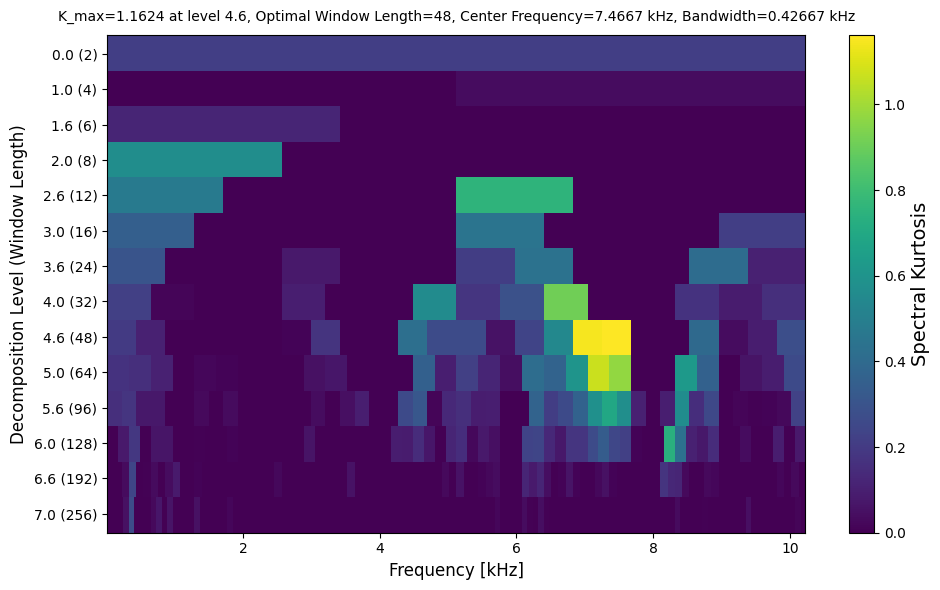

Fs: 20480.0
Fc: 7040.0
Nyquist: 10240.0
Lowcut: 0.6666666666666667
Highcut: 0.7083333333333333
signal : [ 2.77584997 -0.15226993 -0.07216864 ... -1.23268682 -1.49092878
 -0.29089726]


(0.0, 400.0)

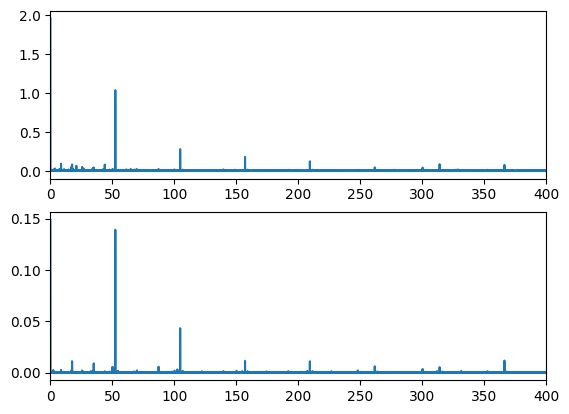

In [256]:
N = 819
Delta = 50
x,r = DRS(signal, N, Delta)

Kwav, Level_w, freq_w, fc, bandwidth = fast_kurtogram(x,fs,nlevel=7, verbose=False)
plot_kurtogram(signal, fs,nlevel=7,verbose=False)

filtered_signal = bandpass_filter(signal, fs, fc, bandwidth,order = 20)

plt.figure()
plt.subplot(2,1,1)
f,X = envelope(signal, fs)
plt.plot(f, X)
plt.xlim((0, 400))

plt.subplot(2,1,2)
f,X = envelope(filtered_signal, fs)
plt.plot(f, X)
plt.xlim((0, 400))

## Part 3 Bearing fault analysis case study with OpenConmo


## Sources
[1] Chenyu Liu, Alexandre Mauricio, Junyu Qi, Dandan Peng, and Konstantinos
Gryllias. Domain Adaptation Digital Twin for Rolling Element Bearing Prog-
nostics. Annual Conference of the PHM Society, 12(1):10, November 2020.
doi:10.36001/phmconf.2020.v12i1.1294.